In [7]:
import re
import jieba
import seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from collections import Counter
from wordcloud import WordCloud
from gensim import corpora, models
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, precision_recall_curve, accuracy_score, precision_score, f1_score, recall_score, auc, roc_curve
rc = {'font.sans-serif': 'SimHei', 'axes.unicode_minus': False}
seaborn.set(context='notebook', style='ticks', rc=rc)

In [2]:
data = pd.read_csv("data/人民网新闻数据.csv", sep="\t")
data

,新闻类别,标题,发布时间,链接详情,新闻内容
0,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,近日，为纪念中国工农红军长征出发90周年，电子科技大学信息与通信工程学院党委组织师生党员骨干...
1,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,师生们通过专题教学、现场教学、访谈教学等多样化的教学环节，参观青杠坡战斗遗址、红军总司令部旧...
2,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,在太平渡渡口，师生们聆听微党课《突围之痛》，并在渡口纪念碑前重温入党誓词。
3,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,中国好人、78岁的井冈山红军后代胡敬华老先生向师生们讲述了父辈的革命事迹，并勉励大家传承长征...
4,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,此次实践研学活动是学院党委“立爱国志 行长征路”学科特色型实践育人工程的重要环节。自2018...
...,...,...,...,...,...
6080,society,夏日“演出经济”持续升温 这些法律风险要关注,2024-07-15,http://society.people.com.cn/n1/2024/0715/c100...,因下雨看台湿滑，致李某在观看演唱会的过程中摔倒，造成右手腕骨折。经鉴定，李某的损伤构成十级伤残。
6081,society,夏日“演出经济”持续升温 这些法律风险要关注,2024-07-15,http://society.people.com.cn/n1/2024/0715/c100...,主办方虽在演唱会开始前提醒了观众注意自身安全，但并没有在看台添加任何防滑措施。法院认为，李某...
6082,society,夏日“演出经济”持续升温 这些法律风险要关注,2024-07-15,http://society.people.com.cn/n1/2024/0715/c100...,据了解，全国法院审理的因演唱会、音乐节引发的相关纠纷类型主要集中于票务纠纷、知识产权纠纷以及...
6083,society,夏日“演出经济”持续升温 这些法律风险要关注,2024-07-15,http://society.people.com.cn/n1/2024/0715/c100...,北京市第四中级人民法院法官李冬梅建议，一方面应加强对票务代售、中介、分销等环节的监管，优化票...


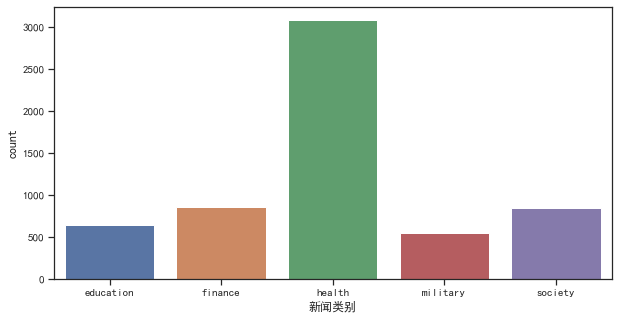

In [3]:
plt.figure(figsize=(10, 5))
seaborn.countplot(x="新闻类别", data=data)
plt.savefig("images/bar_新闻类别.jpg")
plt.show()

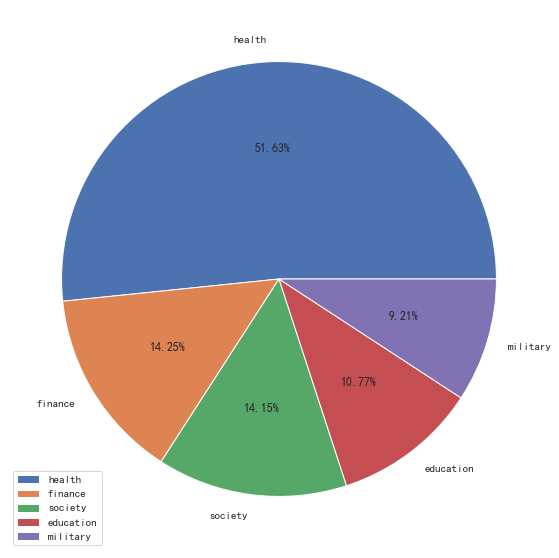

In [4]:
news_count = data["新闻类别"].value_counts().reset_index()
plt.figure(figsize=(10, 10))
plt.pie(x=news_count["新闻类别"].values,labels=news_count["index"],autopct="%.2f%%")
plt.legend()
plt.savefig("images/新闻类别饼图.jpg")
plt.show()

In [5]:
def process_date(date):
    if len(re.split("[-年月日]", str(date)))>1:
        try:
            return int(re.split("[-年月日]", str(date))[1]) 
        except:
            return 0
    else:
        return 0
    
data["month"] = data["发布时间"].apply(lambda x: process_date(x))
data

,新闻类别,标题,发布时间,链接详情,新闻内容,month
0,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,近日，为纪念中国工农红军长征出发90周年，电子科技大学信息与通信工程学院党委组织师生党员骨干...,10
1,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,师生们通过专题教学、现场教学、访谈教学等多样化的教学环节，参观青杠坡战斗遗址、红军总司令部旧...,10
2,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,在太平渡渡口，师生们聆听微党课《突围之痛》，并在渡口纪念碑前重温入党誓词。,10
3,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,中国好人、78岁的井冈山红军后代胡敬华老先生向师生们讲述了父辈的革命事迹，并勉励大家传承长征...,10
4,education,电子科技大学信息与通信工程学院师生赴四川开展红色实践研学活动,2024-10-16,http://edu.people.com.cn/n1/2024/1016/c1006-40...,此次实践研学活动是学院党委“立爱国志 行长征路”学科特色型实践育人工程的重要环节。自2018...,10
...,...,...,...,...,...,...
6080,society,夏日“演出经济”持续升温 这些法律风险要关注,2024-07-15,http://society.people.com.cn/n1/2024/0715/c100...,因下雨看台湿滑，致李某在观看演唱会的过程中摔倒，造成右手腕骨折。经鉴定，李某的损伤构成十级伤残。,7
6081,society,夏日“演出经济”持续升温 这些法律风险要关注,2024-07-15,http://society.people.com.cn/n1/2024/0715/c100...,主办方虽在演唱会开始前提醒了观众注意自身安全，但并没有在看台添加任何防滑措施。法院认为，李某...,7
6082,society,夏日“演出经济”持续升温 这些法律风险要关注,2024-07-15,http://society.people.com.cn/n1/2024/0715/c100...,据了解，全国法院审理的因演唱会、音乐节引发的相关纠纷类型主要集中于票务纠纷、知识产权纠纷以及...,7
6083,society,夏日“演出经济”持续升温 这些法律风险要关注,2024-07-15,http://society.people.com.cn/n1/2024/0715/c100...,北京市第四中级人民法院法官李冬梅建议，一方面应加强对票务代售、中介、分销等环节的监管，优化票...,7


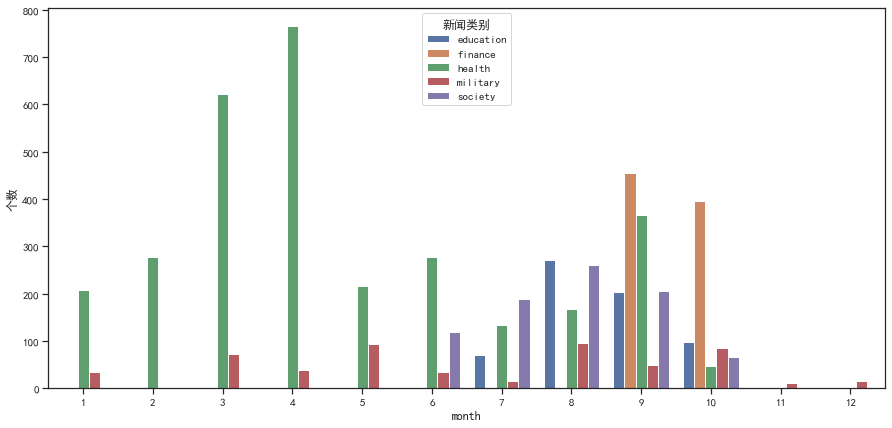

In [6]:
data_month_count = data.loc[data["month"]>0, ["新闻类别", "month", "标题"]].groupby(["新闻类别", "month"]).count().reset_index().rename(columns={"标题":"个数"})
plt.figure(figsize=(15, 7))
seaborn.barplot(x="month",y="个数",hue="新闻类别",data=data_month_count)
plt.savefig("images/不同新闻类别每个月的数量.jpg")
plt.show()

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\zzl20\AppData\Local\Temp\jieba.cache
Loading model cost 0.247 seconds.
Prefix dict has been built successfully.


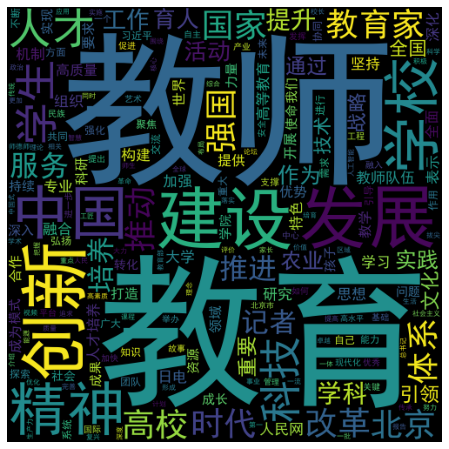

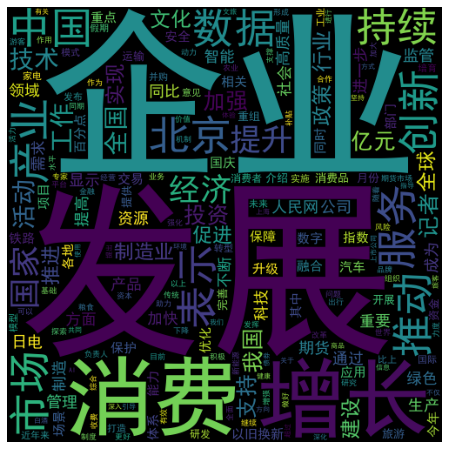

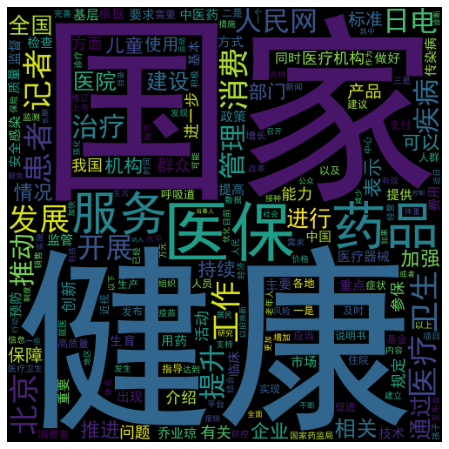

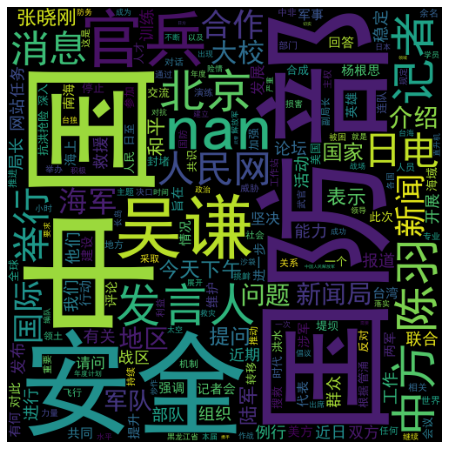

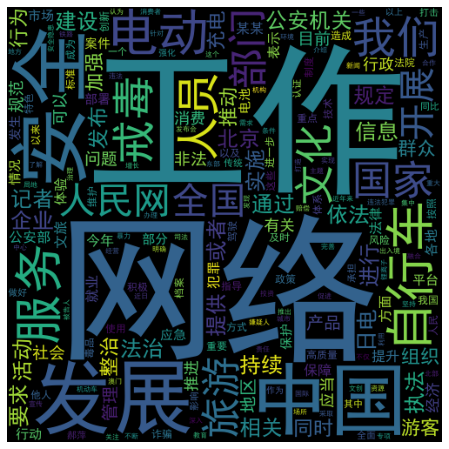

In [7]:
for column in data["新闻类别"].unique():
    try:
        content = data.loc[data["新闻类别"]==column, "新闻内容"].values.tolist()
        word_count = Counter()
        for s in content:
            for word in jieba.lcut(str(s)):
                if len(word) > 1:
                    word_count[str(word)] += 1
        most_common = [item[0] for item in word_count.most_common(500)]
        wc = WordCloud(width=500, height=500, font_path="simhei.ttf")
        wc.generate(" ".join(most_common))
        cloud = wc.to_image()
        cloud.save(f"images/{column}_词云图.jpg")
        plt.figure(figsize=(8,8))
        plt.imshow(cloud)
        plt.axis("off")
        plt.show()
    except:
        continue

In [8]:
# LDA主题建模
def seg_to_list(s):
    return [w for w in jieba.lcut(s) if len(w)>1]

# 数据加载
def load_data(ss):
    doc_list = []
    for s in ss:
        content = "".join(re.findall("[\u4E00-\u9FA5，。！]",s))
        seg_list = seg_to_list(content)
        doc_list.append(seg_list)
    return doc_list

In [9]:
sentences=data.loc[data["新闻内容"].str.len()>10, "新闻内容"].values.tolist()
sentences_list=load_data(sentences)
print(sentences_list[:10])

[['近日', '纪念', '中国工农红军', '长征', '出发', '周年', '电子科技', '大学', '信息', '通信', '工程学院', '党委', '组织', '师生', '党员', '骨干', '前往', '四川', '长征', '干部', '学院', '泸州', '渡赤水', '分院', '开展', '弘扬', '长征', '精神', '赓续', '红色', '血脉', '主题', '红色', '实践', '研学', '活动'], ['师生', '通过', '专题', '教学', '现场', '教学', '访谈', '教学', '多样化', '教学', '环节', '参观', '青杠', '战斗', '遗址', '红军', '总司令部', '旧址', '红军', '纪念馆', '重温', '渡赤水', '历史', '感悟', '伟大', '长征', '精神'], ['太平渡', '渡口', '师生', '聆听', '党课', '突围', '之痛', '渡口', '纪念碑', '重温', '入党', '誓词'], ['中国', '好人', '井冈山', '红军', '后代', '胡敬华', '老先生', '师生', '讲述', '父辈', '革命', '事迹', '勉励', '大家', '传承', '长征', '精神', '党和国家', '事业', '接续', '奋斗', '师生', '深受鼓舞', '纷纷表示', '我们', '长征', '精神', '汲取', '前进', '力量', '践行', '学科', '使命', '担当', '努力', '时代', '科技', '报国', '长征路', '实现', '高水平', '科技', '自立自强', '贡献', '智慧', '力量'], ['此次', '实践', '研学', '活动', '学院', '党委', '爱国', '志行', '长征路', '学科', '特色', '实践', '育人', '工程', '重要环节', '自年', '工程', '四川', '陕西', '贵州', '云南', '福建', '江西', '湖南', '广东', '福建', '西藏', '余地', '建立', '实践', '育人', '基地', '形成', '重走', '二万五千里长征', '时代', '长征路', '学科'

In [10]:
dictionary = corpora.Dictionary(sentences_list)
dictionary.filter_n_most_frequent(200)
corpus = [dictionary.doc2bow(text) for text in sentences_list]
lda = models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, minimum_probability=0.001)
topic_list = lda.print_topics(num_topics=5, num_words=15)  #
print(topic_list)

[(0, '0.003*"保险" + 0.003*"生育" + 0.003*"感染" + 0.003*"老年人" + 0.003*"可能" + 0.002*"疫苗" + 0.002*"减少" + 0.002*"支付" + 0.002*"体重" + 0.002*"一些" + 0.002*"公众" + 0.002*"养老" + 0.002*"传染病" + 0.002*"参保" + 0.002*"接种"'), (1, '0.004*"医疗器械" + 0.004*"修订" + 0.004*"执法" + 0.003*"法治" + 0.003*"依法" + 0.003*"监督" + 0.003*"整治" + 0.003*"提问" + 0.003*"回答" + 0.003*"行政" + 0.002*"国防部" + 0.002*"上市" + 0.002*"年月日" + 0.002*"乔业琼" + 0.002*"案件"'), (2, '0.004*"说明书" + 0.004*"诈骗" + 0.003*"近视" + 0.002*"非法" + 0.002*"军队" + 0.002*"投资" + 0.002*"销售" + 0.002*"百日咳" + 0.002*"论坛" + 0.002*"投诉" + 0.002*"文旅" + 0.002*"用药" + 0.002*"孩子" + 0.002*"他们" + 0.002*"汽车"'), (3, '0.003*"自行车" + 0.003*"公司" + 0.002*"国防部" + 0.002*"参保" + 0.002*"电动" + 0.002*"网站" + 0.002*"购买" + 0.002*"注意" + 0.002*"避免" + 0.002*"发言人" + 0.002*"近期" + 0.002*"集采" + 0.002*"费用" + 0.002*"处理" + 0.002*"犯罪"'), (4, '0.005*"中医药" + 0.005*"电动" + 0.005*"基层" + 0.005*"自行车" + 0.002*"临床" + 0.002*"认证" + 0.002*"专科" + 0.002*"立法" + 0.002*"存在" + 0.002*"机动车" + 0.002*"医疗卫生" + 0.002*"同比" + 0.002*"应急" + 0.00

In [11]:
total_data=[]
for item in topic_list:
    topic_id=item[0]
    words,weight=[],[]
    for line in item[1].replace(" ","").split("+"):
        line_split=line.split("*")
        words.append(line_split[1].replace('"',"").lower())
        weight.append(float(line_split[0]))
    total_data.append(np.expand_dims(words,axis=-1))
    total_data.append(np.expand_dims(weight,axis=-1))

total_data=pd.DataFrame(np.concatenate(total_data,axis=-1),columns=["topic1","权重","topic2","权重","topic3","权重","topic4","权重","topic5","权重"])
total_data

,topic1,权重,topic2,权重,topic3,权重,topic4,权重,topic5,权重
0,保险,0.003,医疗器械,0.004,说明书,0.004,自行车,0.003,中医药,0.005
1,生育,0.003,修订,0.004,诈骗,0.004,公司,0.003,电动,0.005
2,感染,0.003,执法,0.004,近视,0.003,国防部,0.002,基层,0.005
3,老年人,0.003,法治,0.003,非法,0.002,参保,0.002,自行车,0.005
4,可能,0.003,依法,0.003,军队,0.002,电动,0.002,临床,0.002
5,疫苗,0.002,监督,0.003,投资,0.002,网站,0.002,认证,0.002
6,减少,0.002,整治,0.003,销售,0.002,购买,0.002,专科,0.002
7,支付,0.002,提问,0.003,百日咳,0.002,注意,0.002,立法,0.002
8,体重,0.002,回答,0.003,论坛,0.002,避免,0.002,存在,0.002
9,一些,0.002,行政,0.003,投诉,0.002,发言人,0.002,机动车,0.002


In [3]:
data = data.loc[data["新闻内容"].str.len()>10, ["新闻内容","新闻类别"]]
label_dict = {"education":0,"finance":1,"health":2,"military":3,"society":4}
data["新闻类别"] = data["新闻类别"].map(label_dict)
data

,新闻内容,新闻类别
0,近日，为纪念中国工农红军长征出发90周年，电子科技大学信息与通信工程学院党委组织师生党员骨干...,0
1,师生们通过专题教学、现场教学、访谈教学等多样化的教学环节，参观青杠坡战斗遗址、红军总司令部旧...,0
2,在太平渡渡口，师生们聆听微党课《突围之痛》，并在渡口纪念碑前重温入党誓词。,0
3,中国好人、78岁的井冈山红军后代胡敬华老先生向师生们讲述了父辈的革命事迹，并勉励大家传承长征...,0
4,此次实践研学活动是学院党委“立爱国志 行长征路”学科特色型实践育人工程的重要环节。自2018...,0
...,...,...
6080,因下雨看台湿滑，致李某在观看演唱会的过程中摔倒，造成右手腕骨折。经鉴定，李某的损伤构成十级伤残。,4
6081,主办方虽在演唱会开始前提醒了观众注意自身安全，但并没有在看台添加任何防滑措施。法院认为，李某...,4
6082,据了解，全国法院审理的因演唱会、音乐节引发的相关纠纷类型主要集中于票务纠纷、知识产权纠纷以及...,4
6083,北京市第四中级人民法院法官李冬梅建议，一方面应加强对票务代售、中介、分销等环节的监管，优化票...,4


In [4]:
sentences, labels = data["新闻内容"].values.tolist(), data["新闻类别"].values.tolist()
datasets_train, datasets_test, labels_train, labels_test = train_test_split(sentences, labels, train_size=0.8, shuffle=True)

In [5]:
def get_features_tfidf(data_train, data_test):
    vectorizer = CountVectorizer()
    transformer = TfidfTransformer()  # TFIDF model
    train_vectorizer = vectorizer.fit_transform([" ".join(jieba.lcut(sentence)) for sentence in data_train])  # The training dataset was used for TFIDF feature extraction
    test_vectorizer = vectorizer.transform([" ".join(jieba.lcut(sentence)) for sentence in data_test])  # The testng dataset was used for TFIDF feature extraction
    train_tfidf = transformer.fit_transform(train_vectorizer).toarray()
    test_tfidf = transformer.transform(test_vectorizer).toarray()

    return np.array(train_tfidf), np.array(test_tfidf)

def one_hot(y, num_classes=3):
    y_ = np.zeros((len(y), num_classes))
    for i in range(len(y)):
        y_[i, int(y[i])] = 1

    return y_

In [8]:
datasets_train_tfidf, datasets_test_tfidf = get_features_tfidf(datasets_train, datasets_test)
model_pca = PCA(n_components=512)
datasets_train_tfidf = model_pca.fit_transform(datasets_train_tfidf)
datasets_test_tfidf = model_pca.transform(datasets_test_tfidf)
print(datasets_train_tfidf.shape, datasets_test_tfidf.shape)

(4617, 512) (1155, 512)


In [9]:
model_svm = SVC(kernel="rbf", probability=True)
model_svm.fit(datasets_train_tfidf, labels_train)

SVC(probability=True)

In [10]:
labels_pred_svm = model_svm.predict(datasets_test_tfidf)
labels_prob_svm = model_svm.predict_proba(datasets_test_tfidf)
labels_onehot = one_hot(labels_test, 5)
accuracy_svm = accuracy_score(labels_test, labels_pred_svm)
precision_svm = precision_score(labels_test, labels_pred_svm, average="weighted")
recall_svm = recall_score(labels_test, labels_pred_svm, average="weighted")
f1_svm = f1_score(labels_test, labels_pred_svm, average="weighted")
print("SVM")
print(f"accuracy:{accuracy_svm},precision:{precision_svm},recall:{recall_svm},f1_score:{f1_svm}")

SVM
accuracy:0.8718614718614719,precision:0.8694664953147159,recall:0.8718614718614719,f1_score:0.8685167586892636


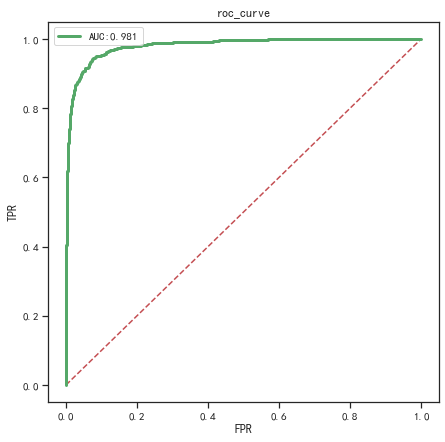

In [11]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "r--")
fpr, tpr, _ = roc_curve(labels_onehot.ravel(), labels_prob_svm.ravel())
plt.plot(fpr, tpr, "g", label=f"AUC:{auc(fpr, tpr):.3f}", linewidth=3.0)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("roc_curve")
plt.legend()
plt.savefig(f"images/svm_roc_curve.jpg")
plt.show()

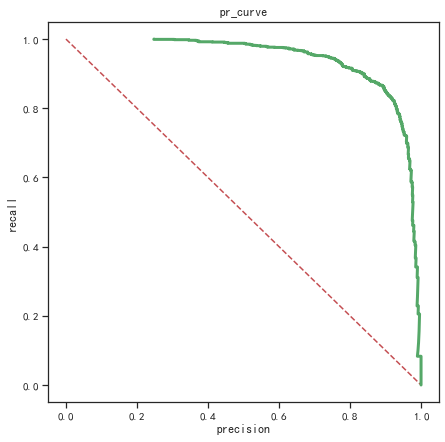

In [12]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [1, 0], "r--")
p, r, _ = precision_recall_curve(labels_onehot.ravel(), labels_prob_svm.ravel())
plt.plot(p, r, "g", linewidth=3.0)
plt.xlabel("precision")
plt.ylabel("recall")
plt.title("pr_curve")
plt.savefig(f"images/svm_pr_curve.jpg")
plt.show()

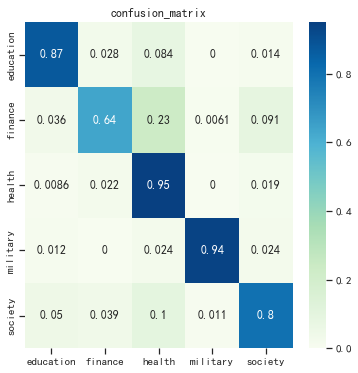

In [13]:
columns = list(label_dict.keys())
matrix = pd.DataFrame(confusion_matrix(labels_test, labels_pred_svm, normalize="true"),columns=columns,index=columns)
plt.figure(figsize=(6, 6))
seaborn.heatmap(matrix, annot=True, cmap="GnBu")
plt.title("confusion_matrix")
plt.savefig(f"images/svm_confusion_matrix.jpg")
plt.show()

In [14]:
model_lr = LogisticRegression(max_iter=3000)
model_lr.fit(datasets_train_tfidf ,labels_train)
labels_pred_lr = model_lr.predict(datasets_test_tfidf)
labels_prob_lr = model_lr.predict_proba(datasets_test_tfidf)

In [15]:
accuracy_lr = accuracy_score(labels_test, labels_pred_lr)
precision_lr = precision_score(labels_test, labels_pred_lr, average="weighted")
recall_lr = recall_score(labels_test, labels_pred_lr, average="weighted")
f1_lr = f1_score(labels_test, labels_pred_lr, average="weighted")
print("Logistic Regression")
print(f"accuracy:{accuracy_lr},precision:{precision_lr},recall:{recall_lr},f1_score:{f1_lr}")

Logistic Regression
accuracy:0.8017316017316017,precision:0.8190938444048553,recall:0.8017316017316017,f1_score:0.7914937737967498


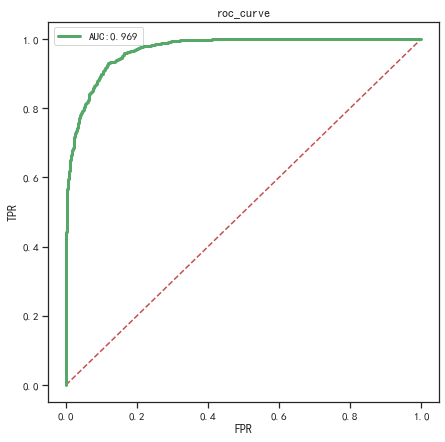

In [16]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "r--")
fpr, tpr, _ = roc_curve(labels_onehot.ravel(), labels_prob_lr.ravel())
plt.plot(fpr, tpr, "g", label=f"AUC:{auc(fpr, tpr):.3f}", linewidth=3.0)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("roc_curve")
plt.legend()
plt.savefig(f"images/lr_roc_curve.jpg")
plt.show()

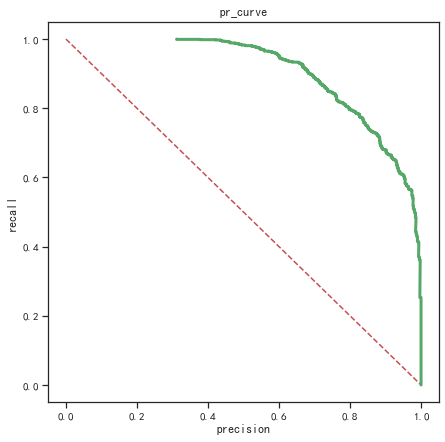

In [17]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [1, 0], "r--")
p, r, _ = precision_recall_curve(labels_onehot.ravel(), labels_prob_lr.ravel())
plt.plot(p, r, "g", linewidth=3.0)
plt.xlabel("precision")
plt.ylabel("recall")
plt.title("pr_curve")
plt.savefig(f"images/lr_pr_curve.jpg")
plt.show()

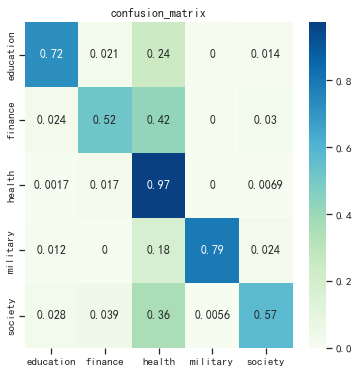

In [18]:
columns = list(label_dict.keys())
matrix = pd.DataFrame(confusion_matrix(labels_test, labels_pred_lr, normalize="true"), columns=columns, index=columns)
plt.figure(figsize=(6, 6))
seaborn.heatmap(matrix, annot=True, cmap="GnBu")
plt.title("confusion_matrix")
plt.savefig(f"images/lr_confusion_matrix.jpg")
plt.show()

In [22]:
model_nb = GaussianNB()
model_nb.fit(datasets_train_tfidf, labels_train)
labels_pred_nb = model_nb.predict(datasets_test_tfidf)
labels_prob_nb = model_nb.predict_proba(datasets_test_tfidf)

In [23]:
accuracy_nb = accuracy_score(labels_test, labels_pred_nb)
precision_nb = precision_score(labels_test, labels_pred_nb, average="weighted")
recall_nb = recall_score(labels_test, labels_pred_nb, average="weighted")
f1_nb = f1_score(labels_test, labels_pred_nb, average="weighted")
print("Naive Bayes:")
print(f"accuracy:{accuracy_nb},precision:{precision_nb},recall:{recall_nb},f1_score:{f1_nb}")

Naive Bayes:
accuracy:0.5411255411255411,precision:0.7125626369728546,recall:0.5411255411255411,f1_score:0.5833278014656037


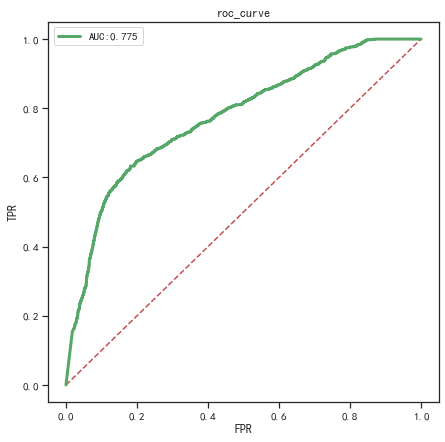

In [24]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "r--")
fpr, tpr, _ = roc_curve(labels_onehot.ravel(), labels_prob_nb.ravel())
plt.plot(fpr, tpr, "g", label=f"AUC:{auc(fpr, tpr):.3f}", linewidth=3.0)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("roc_curve")
plt.legend()
plt.savefig(f"images/nb_roc_curve.jpg")
plt.show()

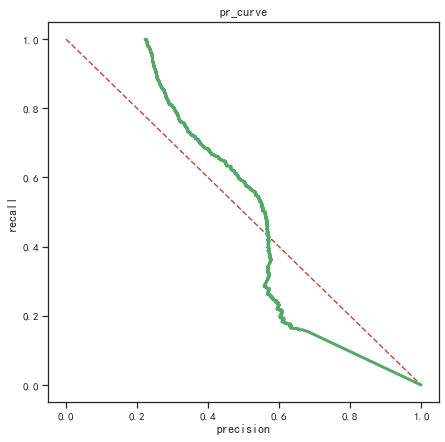

In [25]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [1, 0], "r--")
p, r, _ = precision_recall_curve(labels_onehot.ravel(), labels_prob_nb.ravel())
plt.plot(p, r, "g", linewidth=3.0)
plt.xlabel("precision")
plt.ylabel("recall")
plt.title("pr_curve")
plt.savefig(f"images/nb_pr_curve.jpg")
plt.show()

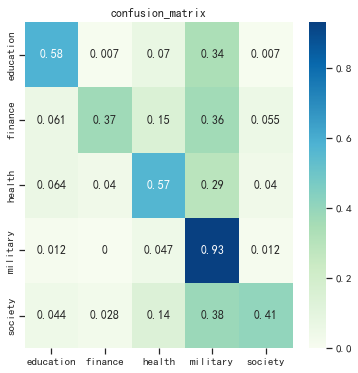

In [26]:
columns = list(label_dict.keys())
matrix = pd.DataFrame(confusion_matrix(labels_test, labels_pred_nb, normalize="true"), columns=columns, index=columns)
plt.figure(figsize=(6, 6))
seaborn.heatmap(matrix, annot=True, cmap="GnBu")
plt.title("confusion_matrix")
plt.savefig(f"images/nb_confusion_matrix.jpg")
plt.show()

In [29]:
model_rf = RandomForestClassifier(n_estimators=200, criterion="entropy")
model_rf.fit(datasets_train_tfidf, labels_train)
labels_pred_rf = model_rf.predict(datasets_test_tfidf)
labels_prob_rf = model_rf.predict_proba(datasets_test_tfidf)

In [30]:
accuracy_rf = accuracy_score(labels_test, labels_pred_rf)
precision_rf = precision_score(labels_test, labels_pred_rf, average="weighted")
recall_rf = recall_score(labels_test, labels_pred_rf, average="weighted")
f1_rf = f1_score(labels_test, labels_pred_rf, average="weighted")
print("Random Forest:")
print(f"accuracy:{accuracy_rf},precision:{precision_rf},recall:{recall_rf},f1_score:{f1_rf}")

Random Forest:
accuracy:0.7220779220779221,precision:0.7754509646569276,recall:0.7220779220779221,f1_score:0.6881473486739343


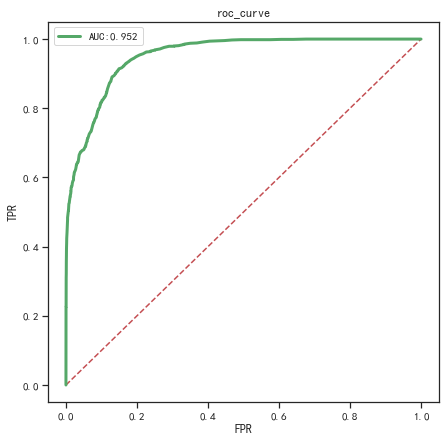

In [31]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "r--")
fpr, tpr, _ = roc_curve(labels_onehot.ravel(), labels_prob_rf.ravel())
plt.plot(fpr, tpr, "g", label=f"AUC:{auc(fpr, tpr):.3f}", linewidth=3.0)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("roc_curve")
plt.legend()
plt.savefig(f"images/rf_roc_curve.jpg")
plt.show()

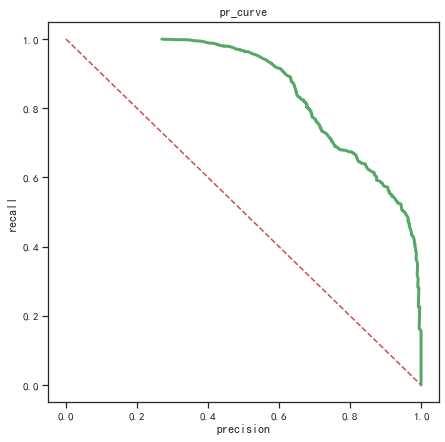

In [32]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [1, 0], "r--")
p, r, _ = precision_recall_curve(labels_onehot.ravel(), labels_prob_rf.ravel())
plt.plot(p, r, "g", linewidth=3.0)
plt.xlabel("precision")
plt.ylabel("recall")
plt.title("pr_curve")
plt.savefig(f"images/rf_pr_curve.jpg")
plt.show()

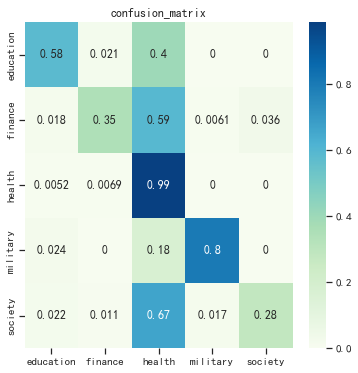

In [33]:
columns = list(label_dict.keys())
matrix = pd.DataFrame(confusion_matrix(labels_test, labels_pred_rf, normalize="true"), columns=columns, index=columns)
plt.figure(figsize=(6, 6))
seaborn.heatmap(matrix, annot=True, cmap="GnBu")
plt.title("confusion_matrix")
plt.savefig(f"images/rf_confusion_matrix.jpg")
plt.show()

In [35]:
model_gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1)
model_gb.fit(datasets_train_tfidf, labels_train)
labels_pred_gb = model_gb.predict(datasets_test_tfidf)
labels_prob_gb = model_gb.predict_proba(datasets_test_tfidf)

In [36]:
accuracy_gb = accuracy_score(labels_test, labels_pred_gb)
precision_gb = precision_score(labels_test, labels_pred_gb, average="weighted")
recall_gb = recall_score(labels_test, labels_pred_gb, average="weighted")
f1_gb = f1_score(labels_test, labels_pred_gb, average="weighted")
print("GBDT:")
print(f"accuracy:{accuracy_gb},precision:{precision_gb},recall:{recall_gb},f1_score:{f1_gb}")

GBDT:
accuracy:0.7645021645021645,precision:0.7625277237495282,recall:0.7645021645021645,f1_score:0.7532787581622464


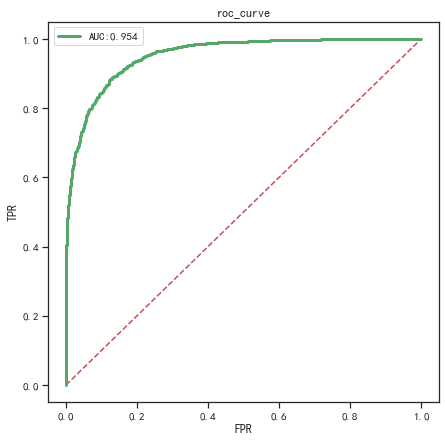

In [37]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "r--")
fpr, tpr, _ = roc_curve(labels_onehot.ravel(), labels_prob_gb.ravel())
plt.plot(fpr, tpr, "g", label=f"AUC:{auc(fpr, tpr):.3f}", linewidth=3.0)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("roc_curve")
plt.legend()
plt.savefig(f"images/gb_roc_curve.jpg")
plt.show()

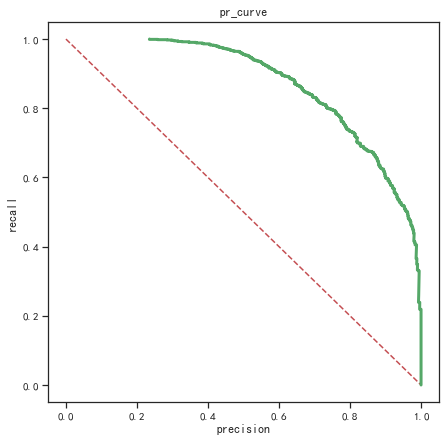

In [38]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [1, 0], "r--")
p, r, _ = precision_recall_curve(labels_onehot.ravel(), labels_prob_gb.ravel())
plt.plot(p, r, "g", linewidth=3.0)
plt.xlabel("precision")
plt.ylabel("recall")
plt.title("pr_curve")
plt.savefig(f"images/gb_pr_curve.jpg")
plt.show()

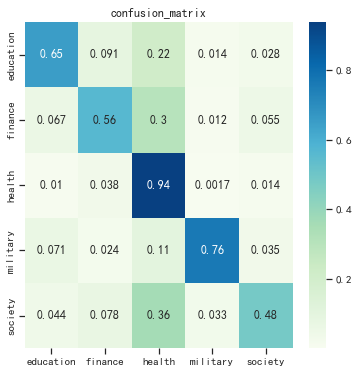

In [39]:
columns = list(label_dict.keys())
matrix = pd.DataFrame(confusion_matrix(labels_test, labels_pred_gb, normalize="true"), columns=columns, index=columns)
plt.figure(figsize=(6, 6))
seaborn.heatmap(matrix, annot=True, cmap="GnBu")
plt.title("confusion_matrix")
plt.savefig(f"images/gb_confusion_matrix.jpg")
plt.show()